## Основная идея / решаемая проблема

В условиях совершенствования сложных технологических инструментов для измерения образовательных результатов, возникает задача глубокого анализа паттернов работы учащихся в цифровой среде с тем, чтобы выявить различия между пользователями с разным уровнем компетентности. Проблема состоит в том, что требуется адаптация и проверка сложных математических моделей и подходов процессного майнинга, успешно используемых в других сферах (банки, телеком).

## Цель и задачи проекта

Цель проекта – отобрать и предложить математическую модель и алгоритмы анализа данных логов о работе учащихся с тем, чтобы можно было выявить паттерны их работы. 
Задачи: 
1. Знакомство с литературой по процессному майнингу и анализу логов
2. Отбор подходящей матмодели
3. Написание скрипта
4. Проверка результатов анализа, их обсуждение.

## Первичный анализ

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.dummy import DummyClassifier


from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
import numpy as np

pd.set_option('display.max_columns', 70)

In [3]:
data = pd.read_excel('Спектакль_utf8_2.xlsx', index_col=0) 
data.head(5)

,Username,GGfscore,GGlevel,1TLDCDSILC_log_fulltime,1TLDCDSILC_log_openglasha,1TLDCDSILC_log_exit,1TLDCDSILC_log_firstclick,1TLDCDSILC_log_loginchoose,1TLDCDSILC_log_help,1TLDCDSILC_log_commtypes,1TLDCDSILC_log_commname,1TLDCDSILC_log_commеtheme,1TLDCDSILC_log_commdescription,1TLDCDSILC_log_commfoto,1TLDCDSILC_log_privacy,1TLDCDSILC_log_notion,1TLDCDSILC_log_savepicture,1TLDCDSILC_log_authorN,1TLDCDSILC_log_authortime,1TLDCDSILC_log_savepictureN,1TLDCDSILC_log_picturechoose,1TLDCDSILC_log_picturechooseN,1TLDCDSILC_log_picturechoosedelete,1TLDCDSILC_log_citation,1TLDCDSILC_log_citationcode,1TLDCDSILC_log_mail1,1TLDCDSILC_log_mail2,1TLDCDSILC_log_wall1,1TLDCDSILC_log_private1,1TLDCDSILC_log_private2,1TLDCDSILC_log_wall2,1TLDCDSILC_log_wall2comment3,1TLDCDSILC_log_wall2comment4,1TLDCDSILC_log_wall2comment5,1TLDCDSILC_log_private3,1TLDCDSILC_log_private4,1TLDCDSILC_log_private5,1TLDCDSILC_log_private6,1TLDCDSILC_log_wall3,1TLDCDSILC_log_wall4,1TLDCDSILC_log_copymail,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5667001,0.726641,2,767,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,NaN,NaN,1,4,1,NaN,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5667003,0.185260,2,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5667005,1.258590,3,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5667007,1.478135,3,871,1,0,поиск,Pom_Rezh125%,0,Мероприятие,Наш спектакль «Сон в летнюю ночь»,Постановка спектакля,Всем привет! Это сообщество создано для участн...,Изображение 1,Закрытое,1,"1,5,3,2,4",NaN,NaN,5,2.4,3,5.1,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,2,3,2,3,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5667009,1.861262,3,631,6,0,почта,Pom_Rezh125%,0,Мероприятие,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 3,Закрытое,1,2.1,NaN,NaN,2,2,1,1,d_teatro.diary.org,2,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",5,4,1,3,3,3,6,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data = data.drop(['GGfscore','Username','Unnamed: 42','Unnamed: 43','Unnamed: 44','Unnamed: 45','Unnamed: 46','Unnamed: 47','Unnamed: 48','Unnamed: 49','Unnamed: 50','Unnamed: 51','Unnamed: 52'], axis=1)

In [5]:
data.head(5)

,GGlevel,1TLDCDSILC_log_fulltime,1TLDCDSILC_log_openglasha,1TLDCDSILC_log_exit,1TLDCDSILC_log_firstclick,1TLDCDSILC_log_loginchoose,1TLDCDSILC_log_help,1TLDCDSILC_log_commtypes,1TLDCDSILC_log_commname,1TLDCDSILC_log_commеtheme,1TLDCDSILC_log_commdescription,1TLDCDSILC_log_commfoto,1TLDCDSILC_log_privacy,1TLDCDSILC_log_notion,1TLDCDSILC_log_savepicture,1TLDCDSILC_log_authorN,1TLDCDSILC_log_authortime,1TLDCDSILC_log_savepictureN,1TLDCDSILC_log_picturechoose,1TLDCDSILC_log_picturechooseN,1TLDCDSILC_log_picturechoosedelete,1TLDCDSILC_log_citation,1TLDCDSILC_log_citationcode,1TLDCDSILC_log_mail1,1TLDCDSILC_log_mail2,1TLDCDSILC_log_wall1,1TLDCDSILC_log_private1,1TLDCDSILC_log_private2,1TLDCDSILC_log_wall2,1TLDCDSILC_log_wall2comment3,1TLDCDSILC_log_wall2comment4,1TLDCDSILC_log_wall2comment5,1TLDCDSILC_log_private3,1TLDCDSILC_log_private4,1TLDCDSILC_log_private5,1TLDCDSILC_log_private6,1TLDCDSILC_log_wall3,1TLDCDSILC_log_wall4,1TLDCDSILC_log_copymail
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2,767,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,NaN,NaN,1,4,1,NaN,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru
2,2,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
3,3,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
4,3,871,1,0,поиск,Pom_Rezh125%,0,Мероприятие,Наш спектакль «Сон в летнюю ночь»,Постановка спектакля,Всем привет! Это сообщество создано для участн...,Изображение 1,Закрытое,1,"1,5,3,2,4",NaN,NaN,5,2.4,3,5.1,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,2,3,2,3,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...
5,3,631,6,0,почта,Pom_Rezh125%,0,Мероприятие,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 3,Закрытое,1,2.1,NaN,NaN,2,2,1,1,d_teatro.diary.org,2,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",5,4,1,3,3,3,6,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2796 entries, 1 to 2796
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   GGlevel                             2796 non-null   int64 
 1   1TLDCDSILC_log_fulltime             2759 non-null   object
 2   1TLDCDSILC_log_openglasha           2759 non-null   object
 3   1TLDCDSILC_log_exit                 2747 non-null   object
 4   1TLDCDSILC_log_firstclick           2046 non-null   object
 5   1TLDCDSILC_log_loginchoose          2751 non-null   object
 6   1TLDCDSILC_log_help                 2759 non-null   object
 7   1TLDCDSILC_log_commtypes            2728 non-null   object
 8   1TLDCDSILC_log_commname             2728 non-null   object
 9   1TLDCDSILC_log_commеtheme           2728 non-null   object
 10  1TLDCDSILC_log_commdescription      2725 non-null   object
 11  1TLDCDSILC_log_commfoto             2725 non-null   object
 1

## Предобработка

#### Замена названий колонок

In [7]:
data = data.rename(
    columns={
        '1TLDCDSILC_log_fulltime': 'fulltime',
        '1TLDCDSILC_log_openglasha':'openglasha',
        '1TLDCDSILC_log_exit':'exit',
        '1TLDCDSILC_log_firstclick':'firstclick',
        '1TLDCDSILC_log_loginchoose':'loginchoose',
        '1TLDCDSILC_log_help':'help',
        '1TLDCDSILC_log_commtypes':'commtypes',
        '1TLDCDSILC_log_commname':'commname',
        '1TLDCDSILC_log_commеtheme':'commеtheme',
        '1TLDCDSILC_log_commdescription':'commdescription',
        '1TLDCDSILC_log_commfoto':'commfoto',
        '1TLDCDSILC_log_privacy':'privacy',
        '1TLDCDSILC_log_notion':'notion',
        '1TLDCDSILC_log_savepicture':'savepicture',
        '1TLDCDSILC_log_authorN':'authorN',
        '1TLDCDSILC_log_authortime':'authortime',
        '1TLDCDSILC_log_savepictureN':'savepictureN',
        '1TLDCDSILC_log_picturechoose':'picturechoose',
        '1TLDCDSILC_log_picturechooseN':'picturechooseN',
        '1TLDCDSILC_log_picturechoosedelete':'picturechoosedelete',
        '1TLDCDSILC_log_citation':'citation',
        '1TLDCDSILC_log_citationcode':'citationcode',
        '1TLDCDSILC_log_mail1':'mail1',
        '1TLDCDSILC_log_mail2':'mail2',
        '1TLDCDSILC_log_wall1':'wall1',
        '1TLDCDSILC_log_private1':'private1',
        '1TLDCDSILC_log_private2':'private2',
        '1TLDCDSILC_log_wall2':'wall2',
        '1TLDCDSILC_log_wall2comment3':'wall2comment3',
        '1TLDCDSILC_log_wall2comment4':'wall2comment4',
        '1TLDCDSILC_log_wall2comment5':'wall2comment5',
        '1TLDCDSILC_log_private3':'private3',
        '1TLDCDSILC_log_private4':'private4',
        '1TLDCDSILC_log_private5':'private5',
        '1TLDCDSILC_log_private6':'private6',
        '1TLDCDSILC_log_wall3':'wall3',
        '1TLDCDSILC_log_wall4':'wall4',
        '1TLDCDSILC_log_copymail':'copymail'
    }
)

In [8]:
data.head(5)

,GGlevel,fulltime,openglasha,exit,firstclick,loginchoose,help,commtypes,commname,commеtheme,commdescription,commfoto,privacy,notion,savepicture,authorN,authortime,savepictureN,picturechoose,picturechooseN,picturechoosedelete,citation,citationcode,mail1,mail2,wall1,private1,private2,wall2,wall2comment3,wall2comment4,wall2comment5,private3,private4,private5,private6,wall3,wall4,copymail
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2,767,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,NaN,NaN,1,4,1,NaN,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru
2,2,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
3,3,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
4,3,871,1,0,поиск,Pom_Rezh125%,0,Мероприятие,Наш спектакль «Сон в летнюю ночь»,Постановка спектакля,Всем привет! Это сообщество создано для участн...,Изображение 1,Закрытое,1,"1,5,3,2,4",NaN,NaN,5,2.4,3,5.1,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,2,3,2,3,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...
5,3,631,6,0,почта,Pom_Rezh125%,0,Мероприятие,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 3,Закрытое,1,2.1,NaN,NaN,2,2,1,1,d_teatro.diary.org,2,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",5,4,1,3,3,3,6,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...


**Расшифровка столбцов**
- **GGlevel** - Уровень цг	
- **fulltime** - Суммарное время на выполнении задания
- **openglasha** - Фиксируется количество раз, которое Глаша вызвана самостоятельно респондентом в течение всего выполнения задания (самостоятельные клики на иконку ассистента) 
- **exit** - Фиксируется нажатие на кнопку “Следующее задание” 
- **firstclick** - Фиксируется название вкладки (после открытой по дефолту), по которой сделан первый клик, т.е. вкладка, которая открыта следующей после соцсети: почта, поиск 
- **loginchoose** - Фиксируется какой логин выбрал респондент из трех предложенных в выпадающем списке 
- **help** - Обращения к справке
- **commtypes** - Выбранный тип сообщества, фиксируется текстом, один из возможных: Бизнес, Тематическое сообщество, Бренд или организация, Сообщество по интересам, Публичная страница, Мероприятие 
- **commname** - Выбранное название сообщества, фиксируется текстом, одно из возможных 
- **commеtheme** - Выбранная тематика сообщества, фиксируется текстом 
- **commdescription** - Выбранное описание для сообщества
- **commfot** - Выбранное фото для сообщества(номер/ название)
- **privacу** - Выбранная настройка закрытое/открытое/частное
- **notion** - Фиксируется количество раз, сколько появлялось выделение красным в процессе заполнения данных о сообществе (описание, обложка, настройка закрытое/ открытое/ частное)
- **savepicture** - Фиксируется количество сохранённых изображений (шт, если не сохранил ни одной, то NA)
- **authorN** - Фиксируется суммарное число кликов-переходов по ссылке "Что такое авторское право?" (из-под любого изображения, ДО момента публикации запись, то есть всё то, что он тыкает ПОСЛЕ публикации, не учитывается). (шт int, если не переходил, то NA)
- **authortime** - Фиксируется время чтения поп-апа “Что такое авторское право” (суммарное, при многократном включении поп-апа и до конца модуля 7) (сек, если не переходил, то NA)
- **savepictureN** - Фиксируется количество сохранённых изображений (шт, если не сохранил ни одной, то NA)
- **picturechoose** - Фиксируется выбранная для размещения картинка (1,5,7) если ничего не опубликовал, то NA
- **picturechooseN** - Фиксируется количество опубликованных изображений (шт, если не сохранил ни одной, то NA)
- **picturechoosedelete** - фиксируется, какие фотографии были добавлены к посту и удалены (1,7), записывается в арифметическом порядке, (если не использовалось удаление, то NA)
- **citatio** - Фиксируется вставленный текст к фотоn
- **citationcode** - Фиксируется код вставленных блоков текста (блоки текста закодированы в соответствии со своими изображениями 1,5,7 (хотя бы один блок текста вставлен = 3) если ничего не добавил, то NA
- **mail1** - Фиксируется выбранный ответ после письма учителя 1 (1,2,3)
- **mail2** - Фиксируется выбранный ответ после письма учителя 2 (1,2,3)
- **wall1** - Фиксируется выбранный ответ на 1 сообщение на стене
- **private1** - Фиксируется выбранный ответ на 1 сообщение л/с
- **private2** - Фиксируется выбранный ответ на 2 сообщение л/с
- **wall2** - Фиксируется выбранный ответ на 2 сообщение на стене
- **wall2comment3** - выбранный ответ к комментарию 3
- **wall2comment4** - выбранный ответ к комментарию 4
- **wall2comment5** - выбранный ответ к комментарию 5
- **private3** - Выбранный ответ в 3 л/с
- **private4** - Выбранный ответ в 4 л/с 
- **private5** - Выбранный ответ в  л/с 5
- **private6** - Выбранный ответ в  6 сообщении в л/с
- **wall3** - Выбранный ответ в  3 сообщении на стене (какая выбрана ссылка)
- **wall4** - Выбранный ответ в  4 сообщении на стене
- **copymail** - Копирует текст или контакты

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2796 entries, 1 to 2796
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GGlevel              2796 non-null   int64 
 1   fulltime             2759 non-null   object
 2   openglasha           2759 non-null   object
 3   exit                 2747 non-null   object
 4   firstclick           2046 non-null   object
 5   loginchoose          2751 non-null   object
 6   help                 2759 non-null   object
 7   commtypes            2728 non-null   object
 8   commname             2728 non-null   object
 9   commеtheme           2728 non-null   object
 10  commdescription      2725 non-null   object
 11  commfoto             2725 non-null   object
 12  privacy              2725 non-null   object
 13  notion               2759 non-null   object
 14  savepicture          2704 non-null   object
 15  authorN              824 non-null    object
 16  authortime 

#### Работа с пропусками

In [10]:
# Выведем столбцы с пропусками

position_column = 0
for column in data.columns:
    if data[column].isna().sum() > 0:
        isna_sum = data[column].isna().sum()
        print(data.columns[position_column],'-', isna_sum,'-', round(isna_sum/2405*100,2))
    position_column += 1

fulltime - 37 - 1.54
openglasha - 37 - 1.54
exit - 49 - 2.04
firstclick - 750 - 31.19
loginchoose - 45 - 1.87
help - 37 - 1.54
commtypes - 68 - 2.83
commname - 68 - 2.83
commеtheme - 68 - 2.83
commdescription - 71 - 2.95
commfoto - 71 - 2.95
privacy - 71 - 2.95
notion - 37 - 1.54
savepicture - 92 - 3.83
authorN - 1972 - 82.0
authortime - 1972 - 82.0
savepictureN - 92 - 3.83
picturechoose - 107 - 4.45
picturechooseN - 106 - 4.41
picturechoosedelete - 2023 - 84.12
citation - 1167 - 48.52
citationcode - 1165 - 48.44
mail1 - 121 - 5.03
mail2 - 124 - 5.16
wall1 - 137 - 5.7
private1 - 466 - 19.38
private2 - 144 - 5.99
wall2 - 156 - 6.49
wall2comment3 - 152 - 6.32
wall2comment4 - 153 - 6.36
wall2comment5 - 154 - 6.4
private3 - 177 - 7.36
private4 - 180 - 7.48
private5 - 196 - 8.15
private6 - 211 - 8.77
wall3 - 192 - 7.98
wall4 - 204 - 8.48
copymail - 291 - 12.1


**fulltime**

In [11]:
data['fulltime'].unique()

array([767, 'undefined', 871, 631, 866, 755, 568, 880, 803, 1143, 686,
       nan, 914, 697, 1188, 661, 678, 775, 937, 1049, 891, 694, 647, 1071,
       517, 885, 721, 705, 829, 635, 746, 771, 763, 1056, 627, 660, 593,
       615, 713, 596, 1035, 1145, 693, 1373, 899, 732, 807, 788, 666, 582,
       962, 670, 711, 834, 1237, 738, 964, 704, 826, 1321, 941, 618, 1501,
       876, 581, 761, 930, 542, 815, 839, 810, 808, 653, 1012, 633, 494,
       809, 780, 984, 1151, 741, 707, 992, 855, 779, 850, 1093, 597, 674,
       884, 532, 548, 605, 623, 498, 748, 650, 709, 696, 781, 637, 598,
       656, 608, 706, 539, 672, 1037, 497, 584, 717, 638, 645, 630, 483,
       1187, 53, 805, 843, 818, 523, 792, 291, 560, 708, 1125, 817, 168,
       567, 549, 725, 690, 342, 1116, 538, 840, 853, 848, 945, 965, 1124,
       936, 1079, 463, 1572, 669, 783, 769, 798, 790, 526, 1164, 49, 1042,
       849, 595, 509, 499, 543, 634, 620, 924, 830, 403, 640, 816, 856,
       446, 325, 928, 905, 782, 1013, 959, 76

In [12]:
data.loc[data['fulltime']=='undefined'] = 0

In [13]:
data.loc[data['fulltime']=='nun'] = 0

In [14]:
data['fulltime'].median()

np.float64(595.0)

In [15]:
# data['fulltime'] = data['fulltime'].fillna(value=data['fulltime'].median())

**openglasha**

In [18]:
data['openglasha'].unique()

array([0, 1, 6, 2, 3, nan, 8, 12, 4, 17, 7, 10, 33, 14, 9, 11, 5, 18, 21,
       24, 50, 26, 16, 15, 30, 20, 13, 19, 25, 29], dtype=object)

In [19]:
data['openglasha'] = data['openglasha'].astype(float).fillna(value=data['openglasha'].median())

In [20]:
data['openglasha'].unique()

array([ 0.,  1.,  6.,  2.,  3.,  8., 12.,  4., 17.,  7., 10., 33., 14.,
        9., 11.,  5., 18., 21., 24., 50., 26., 16., 15., 30., 20., 13.,
       19., 25., 29.])

In [21]:
data['openglasha'] = data['openglasha'].astype(int)

In [22]:
data['openglasha'].unique()

array([ 0,  1,  6,  2,  3,  8, 12,  4, 17,  7, 10, 33, 14,  9, 11,  5, 18,
       21, 24, 50, 26, 16, 15, 30, 20, 13, 19, 25, 29])

In [23]:
data['openglasha'].describe()

count    2796.000000
mean        1.930258
std         3.447194
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        50.000000
Name: openglasha, dtype: float64

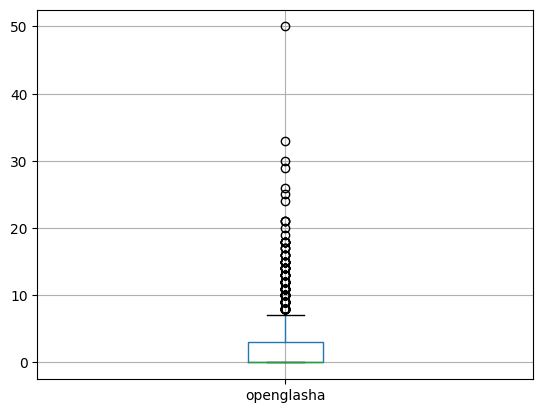

In [24]:
data.loc[:,['openglasha']].boxplot()
plt.show()

**exit**

In [25]:
data['exit'].unique()

array([0, nan, 1, 'поиск', 'почта'], dtype=object)

In [26]:
data = data.dropna(subset=['exit']).reset_index(drop=True)

In [27]:
data['exit'].unique()

array([0, 1, 'поиск', 'почта'], dtype=object)

In [28]:
data['exit'].describe()

count     2747
unique       4
top          0
freq      1846
Name: exit, dtype: int64

**firstclick**

In [29]:
data['firstclick'].unique()

array(['поиск', 0, 'почта', 'соцсеть', 'undefined', nan], dtype=object)

In [30]:
data.loc[data['firstclick']=='undefined'] = 0

In [31]:
data['firstclick'] = data['firstclick'].fillna(value=0)

In [32]:
data['firstclick'].unique()

array(['поиск', 0, 'почта', 'соцсеть'], dtype=object)

**loginchoose**

In [33]:
data['loginchoose'].unique()

array(['Pom_Rezh125%', 0, 'pomrezh', '123abc', 'undefined', nan],
      dtype=object)

In [34]:
data = data.dropna(subset=['loginchoose']).reset_index(drop=True)

In [35]:
data['loginchoose'].unique()

array(['Pom_Rezh125%', 0, 'pomrezh', '123abc', 'undefined'], dtype=object)

**commtypes**

In [36]:
data['commtypes'].unique()

array(['Сообщество по интересам', 0, 'Мероприятие', 'Публичная страница',
       'Тематическое сообщество', 'Бренд или организация', 'Бизнес', nan],
      dtype=object)

In [37]:
data = data.dropna(subset=['commtypes']).reset_index(drop=True)

In [38]:
data['commtypes'].unique()

array(['Сообщество по интересам', 0, 'Мероприятие', 'Публичная страница',
       'Тематическое сообщество', 'Бренд или организация', 'Бизнес'],
      dtype=object)

**commdescription**

In [39]:
data['commdescription'].unique()

array(['Уважаемые участники спектакля! Данное сообщество предназначено для обмена важной информацией о спектакле. Кроме того, Вы можете общаться друг с другом на темы, связанные со спектаклем. Убедительно просим Вас формулировать свои мысли четко и писать в данном сообществе только о деталях постановки. Просим Вас написать администратору сообщества, какие участники спектакля еще не присутствуют здесь.',
       0,
       'Всем привет! Это сообщество создано для участников спектакля. Здесь будет собрана важная информация, и можно просто пообщаться друг с другом. Но комментарии совсем не по делу будут удаляться. Если вы увидите, что каких-то участников тут не хватает, напишите мне.',
       '🎭Сообщество для участников спектакля «Сон в летнюю ночь». Только важное.',
       nan], dtype=object)

In [40]:
data = data.dropna(subset=['commdescription']).reset_index(drop=True)

In [41]:
data['commdescription'].unique()

array(['Уважаемые участники спектакля! Данное сообщество предназначено для обмена важной информацией о спектакле. Кроме того, Вы можете общаться друг с другом на темы, связанные со спектаклем. Убедительно просим Вас формулировать свои мысли четко и писать в данном сообществе только о деталях постановки. Просим Вас написать администратору сообщества, какие участники спектакля еще не присутствуют здесь.',
       0,
       'Всем привет! Это сообщество создано для участников спектакля. Здесь будет собрана важная информация, и можно просто пообщаться друг с другом. Но комментарии совсем не по делу будут удаляться. Если вы увидите, что каких-то участников тут не хватает, напишите мне.',
       '🎭Сообщество для участников спектакля «Сон в летнюю ночь». Только важное.'],
      dtype=object)

**savepicture**

In [42]:
data['savepicture'].unique()

array([4, 0, '1,5,3,2,4', 2.1, 2, '1,3,2', 3.5, 5.2, '2,5,3', '2,4,5',
       '1,5,2,3,4', 2.5, 7, '4,5,2', 2.4, 4.2, 3, 5, 1, '4,2,5', 5.4,
       '3,2,4,5', 6, '5,2,4', '5,2,2', '2,5,8', '5,4,2', 8, '2,5,4', 6.8,
       1.2, '2,4,8,7', '1,2,4', 2.3, 2.8, 2.2, 6.2, '8,3,4', '1,2,3,4,5',
       '2,1,5,8,7', 4.5, '2,7,8', '2,5,6,8,4', 5.5, '1,2,4,5', 3.8, 1.6,
       '1,2,6,5', '1,2,3,5', '2,3,4,5', '7,1,4,2', '2,6,4,8,7,5', '2,8,6',
       '1,5,2', '2,4,6,7,8', 7.5, 8.4, 1.3, '3,1,2', '3,2,1',
       '4,8,7,2,5,6', 7.3, 8.7, '5,2,1,4', 3.3, '1,2,2', '5,2,3,1,4,8',
       '1,2,3', 1.4, '1,2,5', '1,5,5,8,8,8,8,8,7,6,5,2,7,1,1,3,3', 1.1,
       '7,8,2,4,3', 8.5, 6.4, '3,4,7,8', '2,1,4', 3.7, '3,5,8', 6.7,
       '3,1,7', '2,8,7', '1,7,8,3', 8.2, '4,3,2,1,5', '1,2,4,6,7,8',
       '2,1,4,7,8', '4,4,2,2', 3.2, '3,6,5,4', '8,5,1', '1,5,3', 5.6,
       '1,2,8,6', 3.1, '1,3,6', '8,7,5', '5,2,3,8', '2,1,3,5,4', '5,2,5',
       '2,2,4,5', 1.5, nan, '3,5,4', '6,3,7', 4.3, '2,1,7', 5.7, 1.7, 2.7,


In [43]:
data = data.dropna(subset=['savepicture']).reset_index(drop=True)

In [44]:
data['savepicture'].unique()

array([4, 0, '1,5,3,2,4', 2.1, 2, '1,3,2', 3.5, 5.2, '2,5,3', '2,4,5',
       '1,5,2,3,4', 2.5, 7, '4,5,2', 2.4, 4.2, 3, 5, 1, '4,2,5', 5.4,
       '3,2,4,5', 6, '5,2,4', '5,2,2', '2,5,8', '5,4,2', 8, '2,5,4', 6.8,
       1.2, '2,4,8,7', '1,2,4', 2.3, 2.8, 2.2, 6.2, '8,3,4', '1,2,3,4,5',
       '2,1,5,8,7', 4.5, '2,7,8', '2,5,6,8,4', 5.5, '1,2,4,5', 3.8, 1.6,
       '1,2,6,5', '1,2,3,5', '2,3,4,5', '7,1,4,2', '2,6,4,8,7,5', '2,8,6',
       '1,5,2', '2,4,6,7,8', 7.5, 8.4, 1.3, '3,1,2', '3,2,1',
       '4,8,7,2,5,6', 7.3, 8.7, '5,2,1,4', 3.3, '1,2,2', '5,2,3,1,4,8',
       '1,2,3', 1.4, '1,2,5', '1,5,5,8,8,8,8,8,7,6,5,2,7,1,1,3,3', 1.1,
       '7,8,2,4,3', 8.5, 6.4, '3,4,7,8', '2,1,4', 3.7, '3,5,8', 6.7,
       '3,1,7', '2,8,7', '1,7,8,3', 8.2, '4,3,2,1,5', '1,2,4,6,7,8',
       '2,1,4,7,8', '4,4,2,2', 3.2, '3,6,5,4', '8,5,1', '1,5,3', 5.6,
       '1,2,8,6', 3.1, '1,3,6', '8,7,5', '5,2,3,8', '2,1,3,5,4', '5,2,5',
       '2,2,4,5', 1.5, '3,5,4', '6,3,7', 4.3, '2,1,7', 5.7, 1.7, 2.7, 7.2,


**authorN**

In [45]:
data['authorN'].unique()

array([nan, 0, 1, 2, 3, 6], dtype=object)

In [46]:
data['authorN'] = data['authorN'].fillna(value=0)

/var/folders/h0/nh4lklxn6v564l37tbnlfcbh0000gn/T/ipykernel_39163/1235246818.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['authorN'] = data['authorN'].fillna(value=0)


In [47]:
data['authorN'].unique()

array([0, 1, 2, 3, 6])

**authortime**

In [48]:
data['authortime'].unique()

array([nan, 0, 9, 5, 10, 22, 16, 12, 15, 6, 56, 19, 2, 18, 27, 13, 3, 14,
       1, 33, 20, 39, 34, 11, 7, 35, 26, 8, 4, 17, 59, 23, 31, 25, 28, 42,
       21, 36, 138, 30, 29, 24, 41, 46, 37, 38, 49, 48, 57], dtype=object)

In [49]:
data['authortime'] = data['authortime'].fillna(value=0)

/var/folders/h0/nh4lklxn6v564l37tbnlfcbh0000gn/T/ipykernel_39163/907513359.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['authortime'] = data['authortime'].fillna(value=0)


In [50]:
data['authortime'].unique()

array([  0,   9,   5,  10,  22,  16,  12,  15,   6,  56,  19,   2,  18,
        27,  13,   3,  14,   1,  33,  20,  39,  34,  11,   7,  35,  26,
         8,   4,  17,  59,  23,  31,  25,  28,  42,  21,  36, 138,  30,
        29,  24,  41,  46,  37,  38,  49,  48,  57])

**picturechoose**

In [51]:
data['picturechoose'].unique()

array([4, 0, 2.4, 2, 1.3, 3.5, 2.3, '2,4,5', 2.5, 7, 3, 5, 1, 4.5, 6, 8,
       2.8, 1.2, '2,3,4,5', '2,4,8', '2,4,5,6,7,8', '2,6,8', 5.7, nan,
       '1,2,3', 5.8, 4.6, '3,4,7,8', '2,7,8', 1.8, '1,3,5', 6.8,
       '2,3,5,8', '1,2,3,4,5', 1.5, '3,4,5', '1,2,5', '1,2,7', '1,2,4',
       3.4, '2,5,6,7', '2,4,5,8', '2,4,5,6,8', '4,7,8', '2,4,6', 1.6, 4.8,
       '2,4,5,7,8', '2,3,5', 2.6, 7.8, 6.7, '1,2,4,5', '2,5,7,8', '1,2,6',
       1.4, 3.6, '1,2,3,4,5,6,7,8', '2,4,5,7', '2,3,4', 4.7, '2,4,6,8',
       '2,4,6,7,8', '2,5,6,8', '1,4,6,8', 3.8, '4,6,7,8', '2,4,5,6',
       '6,7,8', '1,3,4,5', '2,5,8', '4,5,8', '1,4,5', 2.7, '5,6,7,8',
       '4,6,8', '1,3,5,7,8', '1,2,3,4', '1,5,8', '2,5,7', '1,2,3,5', 5.6,
       '1,3,6,7,8', datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 5, 2, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0),
       datetime.datetime(2024, 7, 5, 0, 0),
       datetime.datetime(2024, 4, 2, 0, 0), '2,4,7'

In [52]:
data = data.dropna(subset=['picturechoose']).reset_index(drop=True)

In [53]:
data['picturechoose'].unique()

array([4, 0, 2.4, 2, 1.3, 3.5, 2.3, '2,4,5', 2.5, 7, 3, 5, 1, 4.5, 6, 8,
       2.8, 1.2, '2,3,4,5', '2,4,8', '2,4,5,6,7,8', '2,6,8', 5.7, '1,2,3',
       5.8, 4.6, '3,4,7,8', '2,7,8', 1.8, '1,3,5', 6.8, '2,3,5,8',
       '1,2,3,4,5', 1.5, '3,4,5', '1,2,5', '1,2,7', '1,2,4', 3.4,
       '2,5,6,7', '2,4,5,8', '2,4,5,6,8', '4,7,8', '2,4,6', 1.6, 4.8,
       '2,4,5,7,8', '2,3,5', 2.6, 7.8, 6.7, '1,2,4,5', '2,5,7,8', '1,2,6',
       1.4, 3.6, '1,2,3,4,5,6,7,8', '2,4,5,7', '2,3,4', 4.7, '2,4,6,8',
       '2,4,6,7,8', '2,5,6,8', '1,4,6,8', 3.8, '4,6,7,8', '2,4,5,6',
       '6,7,8', '1,3,4,5', '2,5,8', '4,5,8', '1,4,5', 2.7, '5,6,7,8',
       '4,6,8', '1,3,5,7,8', '1,2,3,4', '1,5,8', '2,5,7', '1,2,3,5', 5.6,
       '1,3,6,7,8', datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 5, 2, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0),
       datetime.datetime(2024, 7, 5, 0, 0),
       datetime.datetime(2024, 4, 2, 0, 0), '2,4,7',
   

**picturechoosedelete**

In [54]:
data['picturechoosedelete'].unique()

array([nan, 0, 5.1, 1, '2,2,2,2,2', 5.5, 3, '2,4,4', 4, 2, 5,
       '4,2,5,4,4,5', 7, 8, 1.2, 6.6, '2,4,5', '6,2,5,2,6,6', 5.2, 4.2,
       '7,7,5', 6, '4,3,2,1,5', '1,2,5', 3.3, 2.1, '5,4,2', 5.4, 5.6, 8.8,
       5.7, 4.4, 2.5, 2.4, '4,2,7,7,2', 2.2, '5,2,4', '4,3,5,1,2',
       '2,4,8', '1,2,5,4', 6.7, '3,6,3', '2,4,6,8', '5,8,5,2,6', 1.3,
       '4,8,5,2,4', 7.5, 4.8, '4,5,4,5', 3.1, 1.1, '7,1,2', '5,8,5', 5.3,
       '5,2,2', '2,8,6,5', '3,3,3,3', 7.2, 6.2,
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0), '1,3,2', '5,4,5,2',
       datetime.datetime(2024, 4, 2, 0, 0), '2,2,4',
       datetime.datetime(2024, 5, 2, 0, 0), '2.2000000000000002',
       datetime.datetime(2024, 4, 5, 0, 0), '3,1,5', '8,7,8',
       datetime.datetime(2024, 4, 3, 0, 0), '2,2,1',
       datetime.datetime(2024, 1, 2, 0, 0), '6,8,7,5,8', '5,5,4,1',
       '2,5,2,5,4', '5,1,4,2,1,4,5', '2,8,5',
       datetime.datetime(2024, 4, 7, 0, 0),
       datetime.datetime(2024, 5

In [55]:
data['picturechoosedelete'] = data['picturechoosedelete'].fillna(value=0)

In [56]:
data['picturechoosedelete'].unique()

array([0, 5.1, 1, '2,2,2,2,2', 5.5, 3, '2,4,4', 4, 2, 5, '4,2,5,4,4,5', 7,
       8, 1.2, 6.6, '2,4,5', '6,2,5,2,6,6', 5.2, 4.2, '7,7,5', 6,
       '4,3,2,1,5', '1,2,5', 3.3, 2.1, '5,4,2', 5.4, 5.6, 8.8, 5.7, 4.4,
       2.5, 2.4, '4,2,7,7,2', 2.2, '5,2,4', '4,3,5,1,2', '2,4,8',
       '1,2,5,4', 6.7, '3,6,3', '2,4,6,8', '5,8,5,2,6', 1.3, '4,8,5,2,4',
       7.5, 4.8, '4,5,4,5', 3.1, 1.1, '7,1,2', '5,8,5', 5.3, '5,2,2',
       '2,8,6,5', '3,3,3,3', 7.2, 6.2,
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0), '1,3,2', '5,4,5,2',
       datetime.datetime(2024, 4, 2, 0, 0), '2,2,4',
       datetime.datetime(2024, 5, 2, 0, 0), '2.2000000000000002',
       datetime.datetime(2024, 4, 5, 0, 0), '3,1,5', '8,7,8',
       datetime.datetime(2024, 4, 3, 0, 0), '2,2,1',
       datetime.datetime(2024, 1, 2, 0, 0), '6,8,7,5,8', '5,5,4,1',
       '2,5,2,5,4', '5,1,4,2,1,4,5', '2,8,5',
       datetime.datetime(2024, 4, 7, 0, 0),
       datetime.datetime(2024, 5, 3, 

**citation, citationcode**

In [57]:
data['citation'].unique()

array([nan, 0, 'd_teatro.diary.org',
       'zimin.photography.org fomin.blogspot.org',
       'zimin.photography.org ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org ermitazh.theatre.ru',
       'globustheatre.org',
       'ermitazh.theatre.ru d_teatro.diary.org globustheatre.org',
       'shutterstock.com', 'globustheatre.org d_teatro.diary.org',
       'fomin.blogspot.org', 'ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org',
       'ermitazh.theatre.ru globustheatre.org',
       'globustheatre.org ermitazh.theatre.ru', 'liveinternet.ru',
       'd_teatro.diary.org ermitazh.theatre.ru',
       'd_teatro.diary.org zimin.photography.org', 'stockfoto.com',
       'd_teatro.diary.org stockfoto.com',
       'ermitazh.theatre.ru d_teatro.diary.org',
       'd_teatro.diary.org fomin.blogspot.org',
       'shutterstock.com ermitazh.theatre.ru', 'zimin.photography.org',
       'fomin.blogspot.org d_teatro.diary.org zimin.photography.org',
       'fomin.blog

In [58]:
data['citation'] = data['citation'].fillna(value=0)

In [59]:
data['citation'].unique()

array([0, 'd_teatro.diary.org',
       'zimin.photography.org fomin.blogspot.org',
       'zimin.photography.org ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org ermitazh.theatre.ru',
       'globustheatre.org',
       'ermitazh.theatre.ru d_teatro.diary.org globustheatre.org',
       'shutterstock.com', 'globustheatre.org d_teatro.diary.org',
       'fomin.blogspot.org', 'ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org',
       'ermitazh.theatre.ru globustheatre.org',
       'globustheatre.org ermitazh.theatre.ru', 'liveinternet.ru',
       'd_teatro.diary.org ermitazh.theatre.ru',
       'd_teatro.diary.org zimin.photography.org', 'stockfoto.com',
       'd_teatro.diary.org stockfoto.com',
       'ermitazh.theatre.ru d_teatro.diary.org',
       'd_teatro.diary.org fomin.blogspot.org',
       'shutterstock.com ermitazh.theatre.ru', 'zimin.photography.org',
       'fomin.blogspot.org d_teatro.diary.org zimin.photography.org',
       'fomin.blogspot.

In [60]:
data['citationcode'].unique()

array([nan, 0, 2, 3.1, 3.5, '2,4,5', 4, '5,2,4', 7, 4.2, 1, 5, 2.4, 5.4,
       4.5, 6, 2.5, '2,4,4,5', 4.4, 2.3, 8, 2.8, 5.2, 2.1, 7.5, 8.4, 3,
       '1,2,3', 1.8, '5,2,3,8', '1,2,1,3,5,4', '3,5,4', '1,2,5', 5.3,
       '2,4,5,8', '6,8,4,5,2', '2,4,8', 6.8, '5,4,2', 5.8, 2.6,
       '1,1,2,3,4,5', 7.6, 8.2, '2,5,1', '1,7,6', '4,2,8', 8.5, '2,4,5,4',
       '2,4,6,8', '4,2,5', 1.3, 5.7, 2.7, 7.8, '2,2,8,5,2,6,8,5', 3.2,
       '1,2,4,5,8', '4,5,8', 1.2, 5.1, 1.4, '1,2,4', '8,7,6,5', '8,7,2',
       '2,5,4', '4,2,6,5', '2,1,5', 2.2, 5.6, 7.7, 8.1, '5,2,8,7,4', 1.5,
       '2,3,1,4,5', 6.4, datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0), '2,5,5,4',
       datetime.datetime(2024, 4, 2, 0, 0), '2,8,4,2',
       '2.2000000000000002', '4,2,4', datetime.datetime(2024, 2, 5, 0, 0),
       datetime.datetime(2024, 5, 7, 0, 0),
       datetime.datetime(2024, 7, 2, 0, 0),
     

In [61]:
data['citationcode'] = data['citationcode'].fillna(value=0)

In [62]:
data['citationcode'].unique()

array([0, 2, 3.1, 3.5, '2,4,5', 4, '5,2,4', 7, 4.2, 1, 5, 2.4, 5.4, 4.5,
       6, 2.5, '2,4,4,5', 4.4, 2.3, 8, 2.8, 5.2, 2.1, 7.5, 8.4, 3,
       '1,2,3', 1.8, '5,2,3,8', '1,2,1,3,5,4', '3,5,4', '1,2,5', 5.3,
       '2,4,5,8', '6,8,4,5,2', '2,4,8', 6.8, '5,4,2', 5.8, 2.6,
       '1,1,2,3,4,5', 7.6, 8.2, '2,5,1', '1,7,6', '4,2,8', 8.5, '2,4,5,4',
       '2,4,6,8', '4,2,5', 1.3, 5.7, 2.7, 7.8, '2,2,8,5,2,6,8,5', 3.2,
       '1,2,4,5,8', '4,5,8', 1.2, 5.1, 1.4, '1,2,4', '8,7,6,5', '8,7,2',
       '2,5,4', '4,2,6,5', '2,1,5', 2.2, 5.6, 7.7, 8.1, '5,2,8,7,4', 1.5,
       '2,3,1,4,5', 6.4, datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0), '2,5,5,4',
       datetime.datetime(2024, 4, 2, 0, 0), '2,8,4,2',
       '2.2000000000000002', '4,2,4', datetime.datetime(2024, 2, 5, 0, 0),
       datetime.datetime(2024, 5, 7, 0, 0),
       datetime.datetime(2024, 7, 2, 0, 0),
       dat

**mail1, mail2, wall1, private1, private2, wall2, wall2comment3, wall2comment4, wall2comment5, private3, private4, private5, private6, wall3, wall4, copymail**

In [63]:
data = data.dropna(subset=['mail1']).reset_index(drop=True)
data = data.dropna(subset=['mail2']).reset_index(drop=True)
data = data.dropna(subset=['wall1']).reset_index(drop=True)
data = data.dropna(subset=['private1']).reset_index(drop=True)
data = data.dropna(subset=['private2']).reset_index(drop=True)
data = data.dropna(subset=['wall2']).reset_index(drop=True)
data = data.dropna(subset=['wall2comment3']).reset_index(drop=True)
data = data.dropna(subset=['wall2comment4']).reset_index(drop=True)
data = data.dropna(subset=['wall2comment5']).reset_index(drop=True)
data = data.dropna(subset=['private3']).reset_index(drop=True)
data = data.dropna(subset=['private4']).reset_index(drop=True)
data = data.dropna(subset=['private5']).reset_index(drop=True)
data = data.dropna(subset=['private6']).reset_index(drop=True)
data = data.dropna(subset=['wall3']).reset_index(drop=True)
data = data.dropna(subset=['wall4']).reset_index(drop=True)
data = data.dropna(subset=['copymail']).reset_index(drop=True)

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2241 entries, 0 to 2240
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GGlevel              2241 non-null   int64 
 1   fulltime             2241 non-null   object
 2   openglasha           2241 non-null   int64 
 3   exit                 2241 non-null   object
 4   firstclick           2241 non-null   object
 5   loginchoose          2241 non-null   object
 6   help                 2241 non-null   object
 7   commtypes            2241 non-null   object
 8   commname             2241 non-null   object
 9   commеtheme           2241 non-null   object
 10  commdescription      2241 non-null   object
 11  commfoto             2241 non-null   object
 12  privacy              2241 non-null   object
 13  notion               2241 non-null   object
 14  savepicture          2241 non-null   object
 15  authorN              2241 non-null   int64 
 16  author

#### Работа с типом данных

In [65]:
data['fulltime'].unique()

array([767, 0, 871, 631, 866, 755, 568, 803, 1143, 686, 914, 697, 1188,
       661, 678, 775, 937, 1049, 891, 694, 647, 1071, 885, 721, 705, 829,
       746, 771, 763, 1056, 627, 660, 593, 615, 713, 596, 1035, 1145, 693,
       899, 732, 807, 788, 582, 962, 711, 834, 1237, 635, 738, 964, 704,
       826, 618, 1501, 876, 581, 761, 930, 542, 815, 839, 810, 808, 653,
       1012, 633, 494, 809, 780, 984, 1151, 741, 707, 992, 855, 779, 850,
       1093, 597, 884, 532, 548, 605, 623, 498, 748, 709, 696, 781, 598,
       656, 706, 539, 672, 1037, 497, 584, 717, 638, 645, 630, 1187, 843,
       818, 792, 560, 708, 1125, 817, 567, 549, 725, 666, 1116, 538, 840,
       853, 945, 965, 1124, 936, 1079, 463, 1572, 669, 783, 798, 790, 526,
       1042, 849, 595, 499, 941, 634, 403, 640, 816, 856, 446, 325, 928,
       1013, 959, 765, 974, 845, 465, 580, 685, 1018, 1119, 1065, 903,
       574, 1039, 1103, 995, 1324, 999, 1241, 1019, 1267, 1681, 1415,
       1043, 1006, 621, 893, 489, 665, 734, 699, 

In [66]:
data['fulltime'] = data['fulltime'].astype(float).fillna(value=data['fulltime'].median())

In [67]:
# Заменим на int и переведем в минуты
data['fulltime'] = data['fulltime'].astype(int) / 60

In [68]:
data['fulltime'] = data['fulltime'].astype(int)

In [69]:
data['fulltime'].unique()

array([12,  0, 14, 10,  9, 13, 19, 11, 15, 17, 16, 20, 25,  8, 18,  7, 26,
        6,  5, 22, 21, 28, 23, 30, 24, 27])

In [70]:
data['fulltime'] = data['fulltime'].astype(int)

In [71]:
data['fulltime'].describe()

count    2241.000000
mean        7.593485
std         7.078724
min         0.000000
25%         0.000000
50%         9.000000
75%        13.000000
max        30.000000
Name: fulltime, dtype: float64

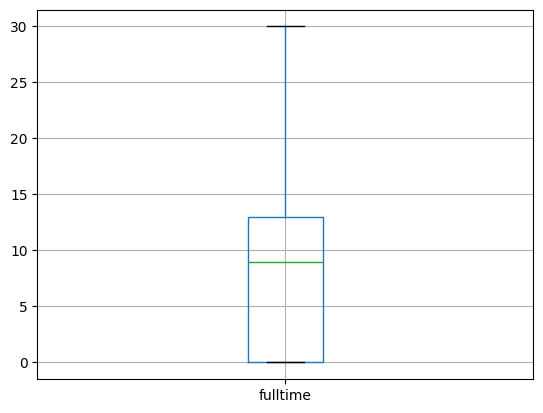

In [72]:
data.loc[:,['fulltime']].boxplot()
plt.show()

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2241 entries, 0 to 2240
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GGlevel              2241 non-null   int64 
 1   fulltime             2241 non-null   int64 
 2   openglasha           2241 non-null   int64 
 3   exit                 2241 non-null   object
 4   firstclick           2241 non-null   object
 5   loginchoose          2241 non-null   object
 6   help                 2241 non-null   object
 7   commtypes            2241 non-null   object
 8   commname             2241 non-null   object
 9   commеtheme           2241 non-null   object
 10  commdescription      2241 non-null   object
 11  commfoto             2241 non-null   object
 12  privacy              2241 non-null   object
 13  notion               2241 non-null   object
 14  savepicture          2241 non-null   object
 15  authorN              2241 non-null   int64 
 16  author

In [74]:
data.head(3)

,GGlevel,fulltime,openglasha,exit,firstclick,loginchoose,help,commtypes,commname,commеtheme,commdescription,commfoto,privacy,notion,savepicture,authorN,authortime,savepictureN,picturechoose,picturechooseN,picturechoosedelete,citation,citationcode,mail1,mail2,wall1,private1,private2,wall2,wall2comment3,wall2comment4,wall2comment5,private3,private4,private5,private6,wall3,wall4,copymail
0,2,12,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,0,0,1,4,1,0,0,0,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [75]:
#Осталось данных в %
print(2241/2796*100)

80.15021459227468


## Работа с преобразованием в числовые значения

In [76]:
categorical_features = ['exit','firstclick','loginchoose','help','commtypes','commname','commеtheme','commdescription','commfoto','privacy','notion','savepicture','savepictureN','picturechoose','picturechooseN','picturechoosedelete','citation','citationcode','mail1','mail2','wall1','private1','private2','wall2','wall2comment3','wall2comment4','wall2comment5','private3','private4','private5','private6','wall3','wall4','copymail']

In [77]:
for e in categorical_features:
    data[e]=data[e].astype(str)

In [78]:
oe = OrdinalEncoder()
df = pd.DataFrame(data)
cat_columns = df.select_dtypes('object').columns

df_oe = oe.fit_transform(df[cat_columns])
df_oe

array([[  0.,   1.,   2., ...,   3.,   3.,  32.],
       [  0.,   0.,   0., ...,   0.,   0.,  16.],
       [  0.,   0.,   0., ...,   0.,   0.,  16.],
       ...,
       [  2.,   0.,   1., ...,   1.,   2., 127.],
       [  2.,   0.,   1., ...,   1.,   4., 215.],
       [  2.,   0.,   2., ...,   3.,   4., 151.]])

In [79]:
df[cat_columns] = df_oe
df

,GGlevel,fulltime,openglasha,exit,firstclick,loginchoose,help,commtypes,commname,commеtheme,commdescription,commfoto,privacy,notion,savepicture,authorN,authortime,savepictureN,picturechoose,picturechooseN,picturechoosedelete,citation,citationcode,mail1,mail2,wall1,private1,private2,wall2,wall2comment3,wall2comment4,wall2comment5,private3,private4,private5,private6,wall3,wall4,copymail
0,2,12,0,0.0,1.0,2.0,0.0,5.0,3.0,2.0,2.0,2.0,1.0,0.0,253.0,0,0,1.0,81.0,1.0,0.0,0.0,0.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,3.0,1.0,3.0,3.0,1.0,5.0,3.0,3.0,32.0
1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
2,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
3,3,14,1,0.0,1.0,2.0,0.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,60.0,0,0,6.0,50.0,5.0,66.0,0.0,0.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,3.0,1.0,2.0,3.0,2.0,3.0,3.0,2.0,121.0
4,3,10,6,0.0,2.0,2.0,0.0,3.0,3.0,2.0,2.0,3.0,1.0,1.0,152.0,0,0,3.0,25.0,1.0,1.0,1.0,13.0,2.0,1.0,2.0,1.0,2.0,1.0,5.0,4.0,1.0,3.0,3.0,3.0,5.0,3.0,2.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2236,0,0,0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,223.0,0,0,5.0,76.0,6.0,38.0,0.0,0.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,17.0
2237,3,0,0,3.0,0.0,1.0,0.0,3.0,3.0,2.0,1.0,3.0,1.0,0.0,179.0,2,22,3.0,62.0,5.0,39.0,26.0,48.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,5.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,172.0
2238,1,0,0,2.0,0.0,1.0,0.0,5.0,3.0,2.0,2.0,4.0,1.0,0.0,177.0,0,0,3.0,57.0,5.0,0.0,1.0,13.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,3.0,5.0,1.0,2.0,127.0
2239,0,0,0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,0,0,1.0,1.0,1.0,0.0,33.0,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,4.0,215.0


## Работа с моделью

In [80]:
features = df.drop(['GGlevel'], axis=1)
target = df['GGlevel']

x, x_test, y, y_test = train_test_split(features, target, test_size=0.2, train_size=0.8)
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size = 0.25, train_size = 0.75)

In [81]:
feature_names = features.columns.tolist()

**Расшифровка**
- x_train, y_train - обучающая выборка
- x_valid, y_valid - валидационная выборка
- x_test, y_test - тестовая выборка

## Исследование модели

**Логистическая регрессия**

In [82]:
#model = LogisticRegression(random_state=12345, solver='lbfgs', max_iter=1000)
#model.fit(x_train, y_train)
#accuracy = model.score(x_valid, y_valid)
#print("Качество:", accuracy)

## Проверка модели на тестовой выборке

**Линейная регрессия**

In [83]:
model = LinearRegression()
model.fit(x_train, y_train)

preds = model.predict(x_test)
accuracy = model.score(x_test, y_test)
model.intercept_, model.coef_

/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-p

(np.float64(-0.01621851434805599),
 array([-7.79692324e-03, -1.69722126e-02, -1.15446307e-01,  1.85249774e-02,
         1.18117831e-01, -8.00466348e-02, -2.98272014e-02,  1.50097844e-01,
         4.57375136e-02, -9.64725045e-03,  2.84954665e-02, -3.94332656e-01,
        -1.34157752e-01, -4.42858650e-04,  7.68195691e-02,  1.99531364e-03,
         1.04385205e-04, -7.02022683e-04,  4.53138197e-02,  1.95877245e-03,
        -4.79209979e-03,  6.94082493e-03, -3.52832316e-02, -1.17265665e-01,
        -5.91786286e-02, -2.31216562e-01,  2.26186554e-01, -3.73399803e-02,
         7.46184080e-02,  1.27240233e-01, -6.24247380e-02,  6.20105687e-02,
         3.55852222e-02,  6.90014537e-02,  1.20528752e-01,  5.52531759e-02,
         1.30561485e-01,  1.44017458e-03]))

In [84]:
def show_coef(names, coef, positive=False):
    tmp_df = pd.Series(index=names, data=coef).sort_values(ascending=False)
    if positive:
        sns.barplot(x=abs(tmp_df.values), y=tmp_df.index)
    else:
        sns.barplot(x=tmp_df.values, y=tmp_df.index)
    plt.tight_layout
    plt.show()

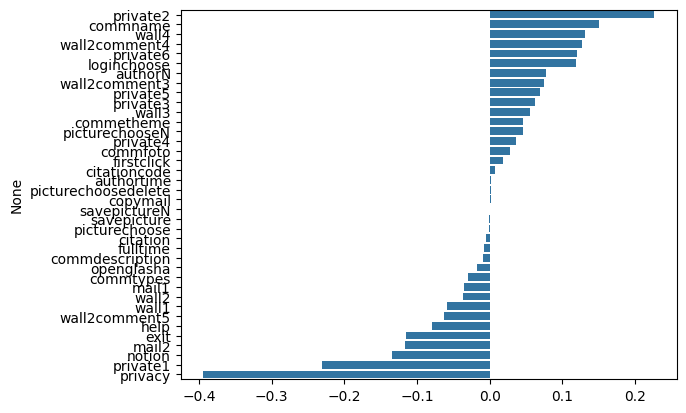

In [85]:
show_coef(feature_names, model.coef_)

## Проверка модели на адекватность

In [86]:
dmc = DummyClassifier(strategy="most_frequent" ,random_state=12345)
dmc.fit(x_train, y_train)
ac_dmc = dmc.score(x_test, y_test)
print("Качество наивного прогноза :", ac_dmc)
print("Качество нашего прогноза :", accuracy)

Качество наивного прогноза : 0.24498886414253898
Качество нашего прогноза : 0.6493142591035754


## Вывод

Исходя из результатов обучения модели можно выделить ключевые параметры, влияющие на итоговую оценку ученика:
1. **privacу** - Выбранная настройка закрытое/открытое/частное
2. **private1** - Фиксируется выбранный ответ на 1 сообщение л/с
3. **mail2** - Фиксируется выбранный ответ после письма учителя 2 (1,2,3)
4. **notion** - Фиксируется количество раз, сколько появлялось выделение красным в процессе заполнения данных о сообществе (описание, обложка, настройка закрытое/ открытое/ частное)
5. **wall2comment5** - выбранный ответ к комментарию 5
6. **private2** - Фиксируется выбранный ответ на 2 сообщение л/с
7. **commname** - Выбранное название сообщества, фиксируется текстом, одно из возможных 
8. **loginchoose** - Фиксируется какой логин выбрал респондент из трех предложенных в выпадающем списке 
9. **wall2comment4** - выбранный ответ к комментарию 4
10. **private6** - Выбранный ответ в  6 сообщении в л/с

Можно разбить ключевые параметра на три группы:
1. private1, private2, private6, mail2 - умение давать верный ответ в личных сообщениях
2. wall2comment5, wall2comment4 - умение отвечать на комментарии
3. privacу, notion, loginchoose - умение правильно задать настройки и оформить сообщество

## Факторный анализ

#### Убедимся, что обычные корреляции нам "ни о чем не говорят"

In [88]:
df_corr = df.corr(method='spearman').unstack().sort_values(ascending=False) \
            .drop_duplicates().reset_index()
df_corr.columns = ['features_1', 'features_2', 'corr']
df_corr_60 = df_corr[(df_corr['corr'] >= 0.6)]
print ('доля вопросов, между которыми корреляция Спирмена 60% и более: {:.0%}'
       .format(len(df_corr_60) / len(df_corr) )) 

доля вопросов, между которыми корреляция Спирмена 60% и более: 3%


#### Проверка данных на возможность проведения на них факторного анализа.

Для того, чтобы определить подходят ли наши данные для факторного анализа, проверим их на критерий Бартлетта и тест Кайзера-Мейера-Олкина (КМО).

In [89]:
df_cc = df.copy()

In [90]:
chi_square_value, p_value = calculate_bartlett_sphericity(df_cc)
chi_square_value, p_value

/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


(np.float64(59396.27201216135), np.float64(0.0))

p-value 0, тест статистически значим

Тест Кайзера-Мейера-Олкина (КМО)

In [91]:
kmo_all, kmo_model = calculate_kmo(df_cc)
kmo_model

np.float64(0.9631765824210806)

KMO более 0.85 (близко к 1), значит данные подходя для проведения факторного анализа. Наши данные подходят для факторного анализа.

#### Определим кол-во факторов

То есть определим количество групп вопросов, результаты которых схожи между собой.

In [92]:
fa = FactorAnalyzer()
fa.fit(df_cc)
ev, v = fa.get_eigenvalues()
ev

/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([15.78555093,  2.46887579,  2.13321036,  1.65156469,  1.4257814 ,
        1.24489067,  0.99981468,  0.91958454,  0.87752885,  0.74060352,
        0.70774333,  0.68855   ,  0.65621685,  0.61756208,  0.54655527,
        0.50548782,  0.47452309,  0.46203758,  0.44449557,  0.43725828,
        0.41416861,  0.39632079,  0.3678533 ,  0.34524145,  0.34072389,
        0.33613652,  0.31954985,  0.31321465,  0.28813687,  0.28305088,
        0.2623287 ,  0.25608135,  0.24180099,  0.21543925,  0.21092424,
        0.17871024,  0.17571   ,  0.16312181,  0.10365129])

Изобразим результат графически.

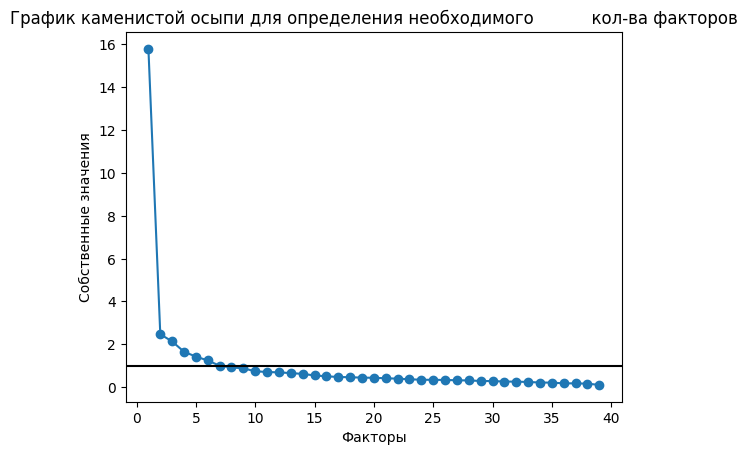

In [93]:
plt.scatter(range(1,df_cc.shape[1]+1),ev)
plt.plot(range(1,df_cc.shape[1]+1),ev)
plt.title('График каменистой осыпи для определения необходимого \
          кол-ва факторов')
plt.xlabel('Факторы')
plt.ylabel('Собственные значения')
plt.axhline(y=1,c='k')
plt.show()

Выделим 8 факторов с собственным значением больше 1, то есть 8 групп вопросов.

Рассчитаем корреляционную матрицу между вопросами и полученными восьмью факторами.

In [94]:
fa = FactorAnalyzer()
fa.set_params(n_factors=8, rotation='varimax')
fa.fit(df_cc)
loadings = fa.loadings_
loadings = np.abs(loadings)

/Users/ildar/Desktop/vsCode/hse/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Сохраним результат в DataFrame.

In [95]:
questions = pd.DataFrame(df.columns,columns=['question'])

In [96]:
questions

,question
0,GGlevel
1,fulltime
2,openglasha
3,exit
4,firstclick
5,loginchoose
6,help
7,commtypes
8,commname
9,commеtheme


In [97]:
df_fa = pd.DataFrame(loadings).reset_index()
df_fa.columns=['№', 'Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5', 'Factor6','Factor7','Factor8']
df_fa = (df_fa.merge(questions['question'], how='left', left_index=True, right_index=True)
         .reindex(columns=['№', 'question', 'Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5', 'Factor6','Factor7','Factor8']))
df_fa

,№,question,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8
0,0,GGlevel,0.514060,0.043687,0.162788,0.197521,0.122668,0.059758,0.254523,0.669009
1,1,fulltime,0.362585,0.850519,0.046391,0.115515,0.038240,0.076047,0.075014,0.041278
2,2,openglasha,0.199164,0.446369,0.028385,0.000453,0.048198,0.030234,0.011870,0.095273
3,3,exit,0.353349,0.884090,0.046509,0.056545,0.063386,0.048064,0.008798,0.030715
4,4,firstclick,0.370286,0.788722,0.041856,0.041267,0.012597,0.064455,0.040647,0.047219
5,5,loginchoose,0.746788,0.079696,0.059852,0.146078,0.050069,0.094055,0.058462,0.038776
6,6,help,0.124855,0.033006,0.004015,0.069645,0.040964,0.036251,0.026776,0.007713
7,7,commtypes,0.732008,0.088948,0.084875,0.141109,0.030155,0.119271,0.053103,0.003307
8,8,commname,0.750759,0.074510,0.110623,0.144643,0.066674,0.081147,0.119706,0.192602
9,9,commеtheme,0.853159,0.097868,0.080614,0.141225,0.037204,0.115358,0.097555,0.002980


Нарисуем тепловую карту с полученными результатами

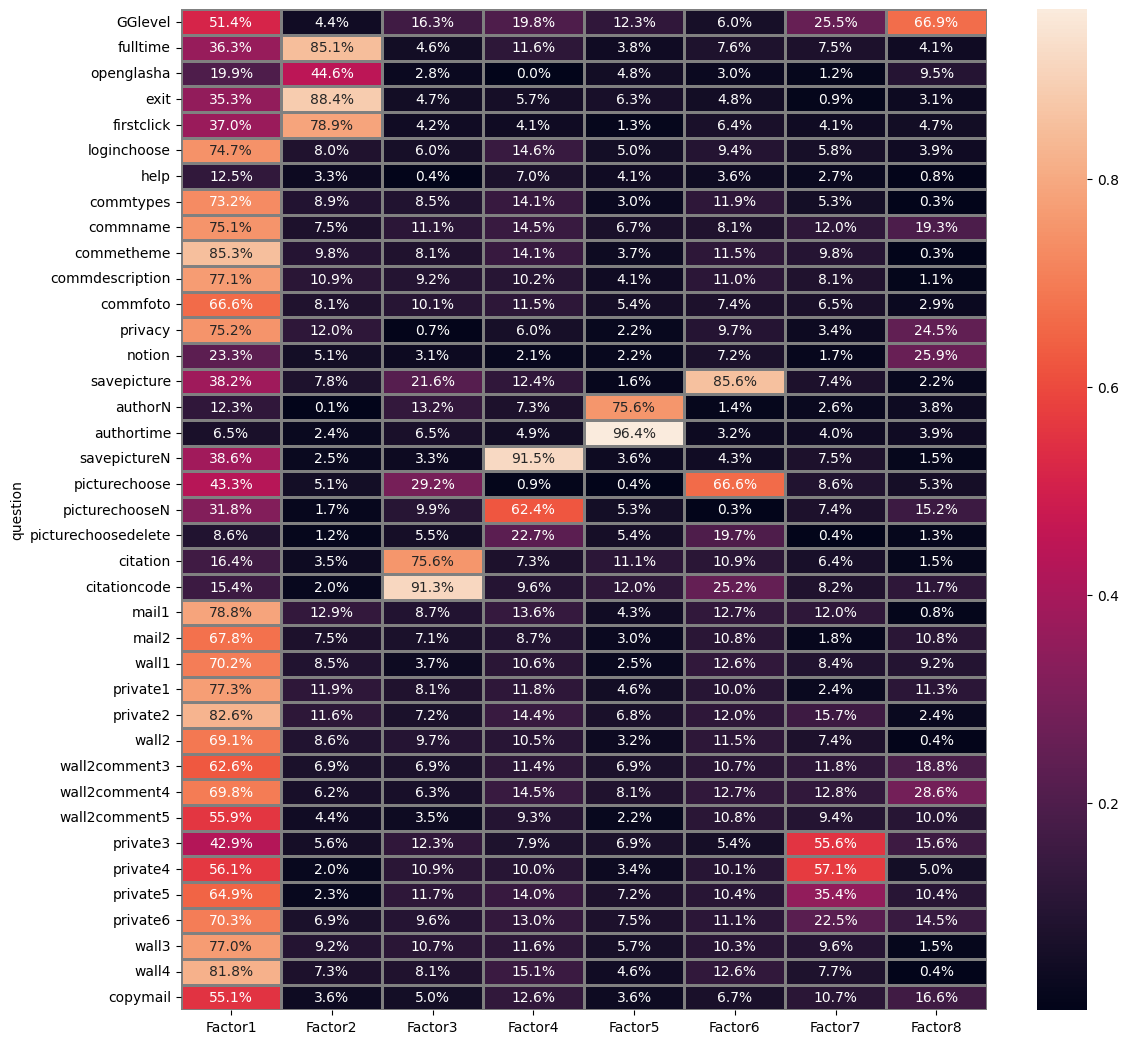

In [98]:
df_fa_pivot = (df_fa.pivot_table(index='question')
               .sort_values(by=['№']).drop(columns=['№']))
plt.figure(figsize=(13, 13))
sns.heatmap(df_fa_pivot, annot=True, fmt='.1%', linewidths=1, linecolor='gray');
plt.show()

In [99]:
averages = df[['GGlevel','fulltime','openglasha','exit','firstclick','loginchoose','help','commtypes','commname','commеtheme','commdescription','commfoto','privacy','notion','savepicture','authorN','authortime','savepictureN','picturechoose','picturechooseN','picturechoosedelete','citation','citationcode','mail1',	'mail2','wall1','private1','private2','wall2','wall2comment3','wall2comment4','wall2comment5','private3','private4','private5','private6','wall3','wall4','copymail']].mean()

In [100]:
averages

GGlevel                  1.376171
fulltime                 7.593485
openglasha               1.815261
exit                     0.566711
firstclick               0.724676
loginchoose              1.687639
help                     0.091031
commtypes                2.948684
commname                 2.007140
commеtheme               1.635431
commdescription          1.530120
commfoto                 2.196341
privacy                  1.068719
notion                   0.511825
savepicture            148.128068
authorN                  0.185631
authortime               2.173137
savepictureN             2.100402
picturechoose           43.053101
picturechooseN           1.991968
picturechoosedelete      5.641678
citation                11.638108
citationcode            20.523427
mail1                    1.427934
mail2                    1.381080
wall1                    1.302544
private1                 0.954485
private2                 1.514949
wall2                    1.840696
wall2comment3 

In [101]:
df_fa

,№,question,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8
0,0,GGlevel,0.514060,0.043687,0.162788,0.197521,0.122668,0.059758,0.254523,0.669009
1,1,fulltime,0.362585,0.850519,0.046391,0.115515,0.038240,0.076047,0.075014,0.041278
2,2,openglasha,0.199164,0.446369,0.028385,0.000453,0.048198,0.030234,0.011870,0.095273
3,3,exit,0.353349,0.884090,0.046509,0.056545,0.063386,0.048064,0.008798,0.030715
4,4,firstclick,0.370286,0.788722,0.041856,0.041267,0.012597,0.064455,0.040647,0.047219
5,5,loginchoose,0.746788,0.079696,0.059852,0.146078,0.050069,0.094055,0.058462,0.038776
6,6,help,0.124855,0.033006,0.004015,0.069645,0.040964,0.036251,0.026776,0.007713
7,7,commtypes,0.732008,0.088948,0.084875,0.141109,0.030155,0.119271,0.053103,0.003307
8,8,commname,0.750759,0.074510,0.110623,0.144643,0.066674,0.081147,0.119706,0.192602
9,9,commеtheme,0.853159,0.097868,0.080614,0.141225,0.037204,0.115358,0.097555,0.002980


In [103]:
averg = pd.DataFrame(averages,columns=['ср.знач']).reset_index()

In [104]:
averg

,index,ср.знач
0,GGlevel,1.376171
1,fulltime,7.593485
2,openglasha,1.815261
3,exit,0.566711
4,firstclick,0.724676
5,loginchoose,1.687639
6,help,0.091031
7,commtypes,2.948684
8,commname,2.007140
9,commеtheme,1.635431


In [105]:
result = pd.concat([df_fa, averg], axis=1, join="inner").reindex(columns=['№','question','ср.знач', 'Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5', 'Factor6','Factor7','Factor8'])
result

,№,question,ср.знач,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8
0,0,GGlevel,1.376171,0.514060,0.043687,0.162788,0.197521,0.122668,0.059758,0.254523,0.669009
1,1,fulltime,7.593485,0.362585,0.850519,0.046391,0.115515,0.038240,0.076047,0.075014,0.041278
2,2,openglasha,1.815261,0.199164,0.446369,0.028385,0.000453,0.048198,0.030234,0.011870,0.095273
3,3,exit,0.566711,0.353349,0.884090,0.046509,0.056545,0.063386,0.048064,0.008798,0.030715
4,4,firstclick,0.724676,0.370286,0.788722,0.041856,0.041267,0.012597,0.064455,0.040647,0.047219
5,5,loginchoose,1.687639,0.746788,0.079696,0.059852,0.146078,0.050069,0.094055,0.058462,0.038776
6,6,help,0.091031,0.124855,0.033006,0.004015,0.069645,0.040964,0.036251,0.026776,0.007713
7,7,commtypes,2.948684,0.732008,0.088948,0.084875,0.141109,0.030155,0.119271,0.053103,0.003307
8,8,commname,2.007140,0.750759,0.074510,0.110623,0.144643,0.066674,0.081147,0.119706,0.192602
9,9,commеtheme,1.635431,0.853159,0.097868,0.080614,0.141225,0.037204,0.115358,0.097555,0.002980


In [850]:
#result=result.drop('index', axis=1)

In [106]:
result.to_excel('education1.xlsx')

### Вывод по факторному анализу

1. Фактор №1 оказывает повышающее влияние на общий результат, так как его балл 5.16, выше, чем общий (2.69). Посмотрим детальнее из чего он состоит.
2. Этот фактор связан:
   - с умением правильно задать настройки(loginchoose,commname,commеtheme,commdescription,commfoto,privacy)
   - c умением давать верный ответ в личных сообщениях(mail1,mail2,private1,private2,private4,private5,private6)
   - с умением отвечать на комментарии(wall1,wall2,wall3,wall4,wall2comment3,wall2comment4,wall2comment5)
3. Наибольшая корреляция фактора с вопросами, связанна с выбранной тематикой сообщества (commetheme - 0,85), выбранным ответом на 2 сообщение л/с (private2 - 0.83) и выбранным ответом на 2 сообщение на стене (wall4 - 0.82)